In [1]:
import math

import torch
import gpytorch
import numpy as np
from matplotlib import pyplot as plt
from sklearn.metrics import mean_squared_error, mean_absolute_error

torch.manual_seed(0)
np.random.seed(0)


R0, P0 = -2.0, -1.5
R1, P1 =  2.0,  1.5
sigma0_R, sigma0_P = 1.0, 2.0
sigma1_R, sigma1_P = 0.5, 0.125

Ntrain, Nval = 100, 10000
NOISE_LEVEL = 1e-5

In [2]:
class WendlandC6Kernel(gpytorch.kernels.Kernel):
    def __init__(self):
        super().__init__()
        self.has_lengthscale = False

    def forward(self, x1, x2, diag=False, **params):
        # x1 == x2 == r (the distance matrix) when called from WendlandExpert
        # BUG 3 FIX: divide by 3 so K(r=0) = 1
        r = x1
        z = torch.clamp(1.0 - r, min=0.0)
        return (z ** 6) * (35 * r ** 2 + 18 * r + 3) / 3


class WendlandExpert(gpytorch.kernels.Kernel):
    is_stationary = True # pyright: ignore[reportAssignmentType]

    def __init__(self, ard_num_dims=2, init_lengthscale=(1.0, 1.0)):
        super().__init__()

        self.base = WendlandC6Kernel()

        # sigmoid-based constraint maps raw back to the intended init values.
        _constraint = gpytorch.constraints.Interval(0.1, 10.0)
        init_ls_tensor = torch.tensor(
            init_lengthscale, dtype=torch.float32
        ).reshape(1, ard_num_dims)

        self.register_parameter(
            name="raw_lengthscale",
            parameter=torch.nn.Parameter(
                _constraint.inverse_transform(init_ls_tensor)
            ),
        )

        self.register_constraint(
            "raw_lengthscale",
            gpytorch.constraints.Interval(0.1, 10.0)
        )

    @property
    def lengthscale(self):
        ls = self.raw_lengthscale_constraint.transform(self.raw_lengthscale) # pyright: ignore[reportCallIssue, reportAttributeAccessIssue]
        return ls.clamp(min=0.1, max=10.0)

    def forward(self, x1, x2, diag=False, **params):
        if diag:
            return torch.ones(x1.shape[0], device=x1.device, dtype=x1.dtype)

        ls = self.lengthscale.clamp(min=0.1)

        x1s = x1 / ls
        x2s = x2 / ls

        dist = torch.cdist(x1s, x2s)
        r = torch.clamp(dist, 0.0, 1.0)

        return self.base(r)

In [3]:
# ============================================================
# GATED MULTI-EXPERT WENDLAND
# ============================================================
 
class MultiWendlandKernel(gpytorch.kernels.Kernel):
    """
    Learned mixture of compact-support Wendland experts with diverse init.
 
    K(x,x') = sum_k w_k(x) w_k(x') K_k^compact(x,x')
 
    Expert lengthscales are initialised log-uniformly over [ls_min, ls_max]
    so that:
      - the finest expert resolves local sharp features (small ls)
      - the coarsest expert captures broader correlations (large ls)
      - each expert starts with a meaningfully different gradient signal
    """
 
    is_stationary = False # pyright: ignore[reportAssignmentType]
 
    def __init__(
        self,
        num_experts: int = 3,
        ls_min: float = 0.3,
        ls_max: float = 4.0
    ):
        super().__init__()
 
        self.num_experts = num_experts
 
        log_scales = torch.linspace(
            torch.log(torch.tensor(ls_min)),
            torch.log(torch.tensor(ls_max)),
            num_experts
        )
        scales = log_scales.exp().tolist()
        init_scales = [(ls, ls) for ls in scales]
 
        self.experts = torch.nn.ModuleList([
            WendlandExpert(ard_num_dims=2, init_lengthscale=ls)
            for ls in init_scales
        ])
 
        self.gate = torch.nn.Sequential(
            torch.nn.Linear(2, 16),
            torch.nn.Tanh(),
            torch.nn.Linear(16, num_experts)
        )
        self._init_gate(num_experts)
 
        print("\n  Expert lengthscale inits:")
        for k, ls in enumerate(init_scales):
            print(f"    Expert {k}: (l_R={ls[0]:.3f}, l_P={ls[1]:.3f})")
 
    def _init_gate(self, num_experts: int, data_scale: float = 3.0):
        """
        Initialise the gating network so that each expert dominates a distinct
        region of input space from step 0.
 
        Strategy
        --------
        Layer 0  (Linear 2 -> 16)
            Orthogonal init scaled by 1/data_scale.  Inputs in
            [-data_scale, data_scale] land in the linear (non-saturated) part
            of Tanh, so gradients flow freely from the first step.
 
        Layer 1  (Linear 16 -> K)
            Near-zero weights + one-hot bias pattern.  Expert k gets bias +B,
            all others get -B.  After softmax this gives expert k a clear
            initial advantage in its dedicated direction while keeping all
            other experts reachable so gradients flow everywhere from step 1.
 
        Result
        ------
        - Hard symmetry-breaking at init: each expert is the clear winner
          along one orthogonal hidden-layer direction.
        - No expert is switched off: all K experts receive gradients from
          step 1.
        - Tanh neurons are in their active (non-saturated) regime: the hidden
          layer is immediately useful rather than needing warm-up epochs.
        """
        L0, L1 = self.gate[0], self.gate[2]
        assert isinstance(L0, torch.nn.Linear) and isinstance(L1, torch.nn.Linear)
 
        # Layer 0: orthogonal weights scaled to the data range
        # Orthogonal rows give maximally diverse input directions.
        # Dividing by data_scale ensures ||W0 x|| ~ 1 for typical inputs,
        # keeping Tanh well away from saturation.
        torch.nn.init.orthogonal_(L0.weight)
        L0.weight.data.mul_(1.0 / data_scale)
        torch.nn.init.zeros_(L0.bias)
 
        # Layer 1: one-hot bias + near-zero weights
        # Near-zero weights mean logits are bias-dominated at init, so the
        # gating pattern is determined by the structured bias, not noise.
        torch.nn.init.normal_(L1.weight, std=0.01)
 
        # Assign each expert a dedicated hidden unit (spaced evenly).
        # Expert k gets: a strong weight on hidden unit h_k, and bias +B.
        # All other experts get bias -B, so softmax gives expert k ~88%
        # probability at its preferred hidden activation (B=2, K=3).
        B = 2.0
        L1.bias.data.fill_(-B)
        stride = L1.weight.shape[1] // num_experts
        for k in range(num_experts):
            h = k * stride
            L1.weight.data[k, h] = 1.0   # amplify response for this expert
            L1.bias.data[k] = B          # give it a positive bias offset
 
    def forward(self, x1, x2, diag=False, **params):
        if diag is True:
            return torch.ones(x1.shape[0], device=x1.device, dtype=x1.dtype)
 
        # BUG 2 FIX: compute per-point gate weights instead of collapsing
        # the batch to a single weight vector with x1.mean(dim=0).
        # g1[i, k] is the weight of expert k for input point x1[i], and
        # similarly for g2. The outer product gives a valid PSD kernel.
        g1 = torch.softmax(self.gate(x1), dim=-1)   # [N, K]
        g2 = torch.softmax(self.gate(x2), dim=-1)   # [M, K]
 
        K_total = torch.zeros(
            x1.shape[0], x2.shape[0],
            device=x1.device, dtype=x1.dtype
        )
        for k, expert in enumerate(self.experts):
            Kk = expert(x1, x2).to_dense()
            wk = g1[:, k].unsqueeze(1) * g2[:, k].unsqueeze(0)  # [N, M]
            K_total = K_total + wk * Kk
 
        return K_total

In [4]:
# ============================================================
# GP MODEL
# ============================================================

class GPModel(gpytorch.models.ExactGP):
    def __init__(self, train_x, train_y, likelihood):
        super().__init__(train_x, train_y, likelihood)
        self.mean_module = gpytorch.means.ZeroMean()
        self.covar_module = gpytorch.kernels.ScaleKernel(
            MultiWendlandKernel(num_experts=3)
        )

    def forward(self, x):
        return gpytorch.distributions.MultivariateNormal(
            self.mean_module(x), # pyright: ignore[reportArgumentType]
            self.covar_module(x)
        )

In [5]:
# ============================================================
# TARGET FUNCTION
# ============================================================


def bimodal(X):
    R, P = X[:, 0], X[:, 1]
    p0 = torch.exp(-0.5 * (((R - R0)/sigma0_R)**2 + ((P - P0)/sigma0_P)**2))
    p1 = 1.8 * torch.exp(-0.5 * (((R - R1)/sigma1_R)**2 + ((P - P1)/sigma1_P)**2))
    return p0 - p1


def gp_diagnostics(model, likelihood, x, y, name="points"):
    model.eval()
    likelihood.eval()

    with torch.no_grad():
        f_pred = model(x).mean
        y_pred = likelihood(model(x)).mean

        mse_f = torch.mean((f_pred - y) ** 2).item()
        mse_y = torch.mean((y_pred - y) ** 2).item()
        noise = likelihood.noise.item()

    print(f"\n===== GP DIAGNOSTICS ({name}) =====")
    print("Noise level:", noise)
    print("\nLatent function vs data (f vs y):")
    print("MSE(f, y):", mse_f)
    print("\nPredictive mean vs data (y_pred vs y):")
    print("MSE(y_pred, y):", mse_y)
    print("\nFirst few comparisons:")
    for i in range(min(5, len(x))):
        print(
            "x =", x[i].tolist(),
            "| y =", y[i].item(),
            "| f =", f_pred[i].item(),
            "| ŷ =", y_pred[i].item()
        )

In [6]:
# ============================================================
# TRAINING
# ============================================================

def train_gp(
    model: gpytorch.models.GP, likelihood: gpytorch.likelihoods.Likelihood,
    train_x: torch.Tensor, train_y: torch.Tensor,
    max_steps     = 500,
    lr            = 0.03,
    window        = 20,
    min_delta     = 1e-4,
    grad_tol      = 1e-4,
    patience      = 80,
):
    """
    Train with three complementary stopping criteria (all must agree to stop):

    1. Loss-window convergence : absolute improvement over the last
       `window` steps is below `min_delta`.
    2. Gradient-norm test      : the L2 norm of all gradients is below
       `grad_tol`, indicating a flat landscape.
    3. Patience / plateau guard: no new best loss for `patience` steps.

    Training also stops at `max_steps` regardless.
    """
    model.train()
    likelihood.train()

    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    mll       = gpytorch.mlls.ExactMarginalLogLikelihood(likelihood, model)

    loss_history     = []
    best_loss        = float("inf")
    steps_since_best = 0
    stop_reason      = f"max steps ({max_steps}) reached"

    for i in range(max_steps):
        optimizer.zero_grad()
        loss = -mll(model(train_x), train_y) # pyright: ignore[reportOperatorIssue]
        loss.backward()

        grad_norm = math.sqrt(sum(
            p.grad.detach().norm().item() ** 2
            for p in model.parameters()
            if p.grad is not None
        ))

        optimizer.step()

        loss_val = loss.item()
        loss_history.append(loss_val)

        if loss_val < best_loss - min_delta:
            best_loss        = loss_val
            steps_since_best = 0
        else:
            steps_since_best += 1

        if (i + 1) % 50 == 0:
            print(f"  Step {i+1:4d} | loss {loss_val:.6f} | "
                  f"grad_norm {grad_norm:.2e} | "
                  f"no-improve {steps_since_best}")

        window_converged = (
            len(loss_history) >= window and
            abs(loss_history[-window] - loss_val) < min_delta
        )
        grad_converged   = grad_norm < grad_tol
        patience_triggered = steps_since_best >= patience

        if window_converged and grad_converged:
            stop_reason = (
                f"converged at step {i+1}  "
                f"(Δloss over {window} steps = "
                f"{abs(loss_history[-window]-loss_val):.2e} < {min_delta:.0e}, "
                f"||grad|| = {grad_norm:.2e} < {grad_tol:.0e})"
            )
            break

        if patience_triggered:
            stop_reason = (
                f"patience triggered at step {i+1}  "
                f"(no improvement for {patience} steps, "
                f"best loss = {best_loss:.6f})"
            )
            break

    total_steps = len(loss_history)
    print(f"\n  Stopped : {stop_reason}")
    print(f"  Steps   : {total_steps}  |  final loss : {loss_history[-1]:.6f}  "
          f"|  best loss : {best_loss:.6f}")
    return loss_history

In [7]:
# ============================================================
# DATA
# ============================================================

def sample_mixture(N):
    N1 = int(0.45*N)
    N2 = int(0.45*N)
    N3 = N - N1 - N2
    R1s = torch.randn(N1)*sigma0_R + R0
    P1s = torch.randn(N1)*sigma0_P + P0
    R2s = torch.randn(N2)*sigma1_R + R1
    P2s = torch.randn(N2)*sigma1_P + P1
    R3s = torch.empty(N3).uniform_(-6, 6)
    P3s = torch.empty(N3).uniform_(-6, 6)
    R = torch.cat([R1s, R2s, R3s])
    P = torch.cat([P1s, P2s, P3s])
    return torch.stack([R, P], dim=-1)

train_x = sample_mixture(Ntrain)
train_y = bimodal(train_x)
val_x = torch.stack([
    torch.empty(Nval).uniform_(-6, 6),
    torch.empty(Nval).uniform_(-6, 6)
], dim=-1)
val_y = bimodal(val_x)


likelihood = gpytorch.likelihoods.GaussianLikelihood(
    noise_constraint=gpytorch.constraints.Interval(1e-6, NOISE_LEVEL)
)
likelihood.noise = torch.tensor(NOISE_LEVEL)
likelihood.noise_covar.raw_noise.requires_grad_(False)
model = GPModel(train_x, train_y, likelihood)


  Expert lengthscale inits:
    Expert 0: (l_R=0.300, l_P=0.300)
    Expert 1: (l_R=1.095, l_P=1.095)
    Expert 2: (l_R=4.000, l_P=4.000)


In [8]:
print("\n================ BEFORE TRAINING ================\n")

model.eval()
likelihood.eval()

with torch.no_grad(), \
     gpytorch.settings.fast_pred_var(), \
     gpytorch.settings.max_cholesky_size(0):
    pred = likelihood(model(val_x)).mean

mse_before = mean_squared_error(val_y.numpy(), pred.numpy())
mae_before = mean_absolute_error(val_y.numpy(), pred.numpy())

print(f"MSE : {mse_before:.6e}")
print(f"MAE : {mae_before:.6e}")

print("Training...")
# BUG 4 FIX: pass train_x and train_y explicitly
loss_history = train_gp(model, likelihood, train_x, train_y, max_steps=8000)


================ BEFORE TRAINING ================

MSE : 3.850681e-03
MAE : 2.730652e-02
Training...
  Step   50 | loss -1.844665 | grad_norm 2.03e-01 | no-improve 0
  Step  100 | loss -2.030324 | grad_norm 1.08e-01 | no-improve 0
  Step  150 | loss -2.122087 | grad_norm 4.91e-02 | no-improve 0
  Step  200 | loss -2.140728 | grad_norm 2.40e-02 | no-improve 0
  Step  250 | loss -2.155633 | grad_norm 1.38e-01 | no-improve 0
  Step  300 | loss -2.165668 | grad_norm 2.44e-02 | no-improve 0
  Step  350 | loss -2.172274 | grad_norm 1.17e-02 | no-improve 0
  Step  400 | loss -2.176246 | grad_norm 2.33e-01 | no-improve 8
  Step  450 | loss -2.179311 | grad_norm 3.45e-01 | no-improve 8
  Step  500 | loss -2.184677 | grad_norm 9.67e-03 | no-improve 4
  Step  550 | loss -2.185000 | grad_norm 4.84e-01 | no-improve 11
  Step  600 | loss -2.188108 | grad_norm 4.37e-01 | no-improve 20
  Step  650 | loss -2.191051 | grad_norm 3.27e-01 | no-improve 8
  Step  700 | loss -2.193022 | grad_norm 2.72e-01 |

In [9]:
# ============================================================
# EVAL
# ============================================================

model.eval()
likelihood.eval()

with torch.no_grad():
    pred = likelihood(model(val_x)).mean

mse = mean_squared_error(val_y.numpy(), pred.numpy())
mae = mean_absolute_error(val_y.numpy(), pred.numpy())
print("\nValidation MSE:", mse)
print("Validation MAE:", mae)

abs_err   = (pred - val_y).abs()
worst_idx = int(abs_err.argmax().item())
worst_pt  = val_x[worst_idx]
worst_err = abs_err[worst_idx].item()
worst_true = val_y[worst_idx].item()
worst_pred = pred[worst_idx].item()

print(f"\n  Worst error point   : R={worst_pt[0]:.4f}, P={worst_pt[1]:.4f}")
print(f"  True value          : {worst_true:.6f}")
print(f"  Predicted value     : {worst_pred:.6f}")
print(f"  Absolute error      : {worst_err:.6f}")


Validation MSE: 0.0002002810506382957
Validation MAE: 0.008137011900544167

  Worst error point   : R=-0.4768, P=1.2626
  True value          : 0.120735
  Predicted value     : 0.007023
  Absolute error      : 0.113712


In [10]:
# ============================================================
# Kernel diagnostics for MULTI-SCALE / ARD Wendland experts
# ============================================================

def kernel_sparsity(model, X, thresholds=(0.0, 1e-8, 1e-6, 1e-4)):
    model.eval()

    with torch.no_grad():
        K = model.covar_module(X).to_dense()
        n = K.shape[0]
        total = n * n

        print("\n" + "─"*60)
        print("KERNEL DIAGNOSTICS")
        print("─"*60)

        kern = model.covar_module.base_kernel
        if hasattr(kern, "kernels"):
            for k in kern.kernels:
                if hasattr(k, "experts"):
                    kern = k
                    break

        print(f"\nLearned expert lengthscales")
        for k, expert in enumerate(kern.experts):
            if expert.lengthscale.ndim == 0:
                ls_string = f"{expert.lengthscale.item():.4f}"
            elif expert.lengthscale.numel() == 1:
                ls_string = f"{expert.lengthscale.squeeze().item():.4f}"
            else:
                lsvals = expert.lengthscale.squeeze().cpu().numpy()
                ls_string = "[" + ", ".join(f"{v:.4f}" for v in lsvals) + "]"
            print(f"    Expert {k}  ls = {ls_string}")

        print(f"\nPer-expert structural zeros")
        for k, expert in enumerate(kern.experts):
            Kk = expert(X, X).to_dense()
            zeros = (Kk.abs() == 0).sum().item()
            if expert.lengthscale.numel() == 1:
                ls_string = f"{expert.lengthscale.squeeze().item():.3f}"
            else:
                lsvals = expert.lengthscale.squeeze().cpu().numpy()
                ls_string = "[" + ", ".join(f"{v:.3f}" for v in lsvals) + "]"
            print(
                f"    Expert {k}  ls={ls_string}  "
                f"→ {zeros}/{total} ({100*zeros/total:.1f}%)"
            )

        if hasattr(kern, "gate"):
            gate_vals = torch.softmax(kern.gate(X), dim=-1)
            print(f"\nGate usage statistics")
            for k in range(gate_vals.shape[-1]):
                gk = gate_vals[:, k]
                print(
                    f"    Expert {k} : "
                    f"mean={gk.mean():.3f}   "
                    f"max={gk.max():.3f}   "
                    f"min={gk.min():.3f}"
                )

        print(f"\nComposite kernel sparsity")
        for tau in thresholds:
            zeros = (K.abs() <= tau).sum().item()
            print(
                f"    |K_ij| ≤ {tau:.0e} "
                f"→ {zeros}/{total} ({100*zeros/total:.1f}%)"
            )

        sv = torch.linalg.svdvals(K)
        sv = sv / (sv.sum() + 1e-12)
        entropy  = -(sv * (sv + 1e-12).log()).sum()
        eff_rank = entropy.exp().item()
        print(f"\nEffective rank : {eff_rank:.2f} / {n}")
        print(f"Rank fraction  : {eff_rank/n:.3f}")

        dist_mat = torch.cdist(X, X)
        dist_mat.fill_diagonal_(float("inf"))
        min_dists = dist_mat.min(dim=1).values
        fill_dist = min_dists.max().item()
        mean_nn   = min_dists.mean().item()
        print(f"\nFill distance    : {fill_dist:.4f}")
        print(f"Mean NN distance : {mean_nn:.4f}")

        eigs    = torch.linalg.eigvalsh(K)
        lam_min = eigs.min().item()
        lam_max = eigs.max().item()
        cond    = lam_max / max(lam_min, 1e-12)
        print(f"\nSpectrum")
        print(f"    λ_min = {lam_min:.4e}")
        print(f"    λ_max = {lam_max:.4e}")
        print(f"    cond  = {cond:.4e}")
        print("─"*60 + "\n")

        return K


K_train = kernel_sparsity(model, train_x)


────────────────────────────────────────────────────────────
KERNEL DIAGNOSTICS
────────────────────────────────────────────────────────────

Learned expert lengthscales
    Expert 0  ls = [0.7874, 0.5997]
    Expert 1  ls = [2.6975, 0.6710]
    Expert 2  ls = [6.5419, 9.9874]

Per-expert structural zeros
    Expert 0  ls=[0.787, 0.600]  → 8388/10000 (83.9%)
    Expert 1  ls=[2.698, 0.671]  → 7574/10000 (75.7%)
    Expert 2  ls=[6.542, 9.987]  → 632/10000 (6.3%)

Gate usage statistics
    Expert 0 : mean=0.019   max=0.360   min=0.000
    Expert 1 : mean=0.476   max=1.000   min=0.000
    Expert 2 : mean=0.505   max=1.000   min=0.000

Composite kernel sparsity
    |K_ij| ≤ 0e+00 → 632/10000 (6.3%)
    |K_ij| ≤ 1e-08 → 5110/10000 (51.1%)
    |K_ij| ≤ 1e-06 → 5232/10000 (52.3%)
    |K_ij| ≤ 1e-04 → 5378/10000 (53.8%)

Effective rank : 11.99 / 100
Rank fraction  : 0.120

Fill distance    : 2.6920
Mean NN distance : 0.4130

Spectrum
    λ_min = 1.2343e-07
    λ_max = 1.8142e+00
    cond  = 

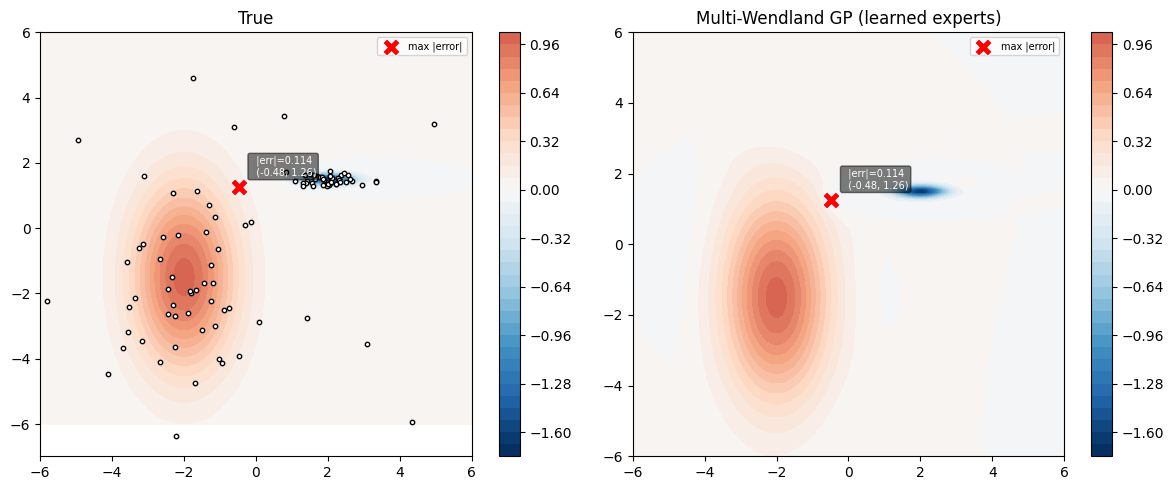

In [11]:
# ============================================================
# GRID PLOT
# ============================================================
 
Nr = Np = 120
R = torch.linspace(-6, 6, Nr)
P = torch.linspace(-6, 6, Np)
RR, PP = torch.meshgrid(R, P, indexing="ij")
Xg = torch.stack([RR.reshape(-1), PP.reshape(-1)], dim=-1)
 
with torch.no_grad():
    chunk  = 2000
    Z_parts = []
    for start in range(0, Xg.shape[0], chunk):
        Z_parts.append(likelihood(model(Xg[start:start+chunk])).mean)
    Z = torch.cat(Z_parts).reshape(Nr, Np)
 
fig, ax = plt.subplots(1, 2, figsize=(12, 5))
 
true_data = bimodal(Xg).reshape(Nr, Np)
# Symmetric colour limits so that zero maps to white in the diverging cmap
vmax = max(true_data.abs().max().item(), Z.abs().max().item())
vmin = -vmax
 
c0 = ax[0].contourf(RR, PP, true_data, levels=40,
                    cmap="RdBu_r", vmin=vmin, vmax=vmax)
ax[0].scatter(train_x[:,0], train_x[:,1], s=10, c='white', edgecolor='black')
ax[0].set_title("True")
fig.colorbar(c0, ax=ax[0])
 
c1 = ax[1].contourf(RR, PP, Z, levels=40,
                    cmap="RdBu_r", vmin=vmin, vmax=vmax)
ax[1].set_title("Multi-Wendland GP (learned experts)")
fig.colorbar(c1, ax=ax[1])
 
for a in ax:
    a.scatter(
        worst_pt[0].item(), worst_pt[1].item(),
        marker="X", s=160, color="red", zorder=5,
        linewidths=0.8, edgecolors="white", label="max |error|"
    )
    a.annotate(
        f"  |err|={worst_err:.3f}\n  ({worst_pt[0]:.2f}, {worst_pt[1]:.2f})",
        xy=(worst_pt[0].item(), worst_pt[1].item()),
        xytext=(8, 8), textcoords="offset points",
        fontsize=7, color="white",
        bbox=dict(boxstyle="round,pad=0.2", fc="black", alpha=0.5)
    )
    a.legend(fontsize=7, loc="upper right")
 
plt.tight_layout()
plt.show()

/tmp/ipykernel_76924/1725819457.py:47: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig_hist.show()


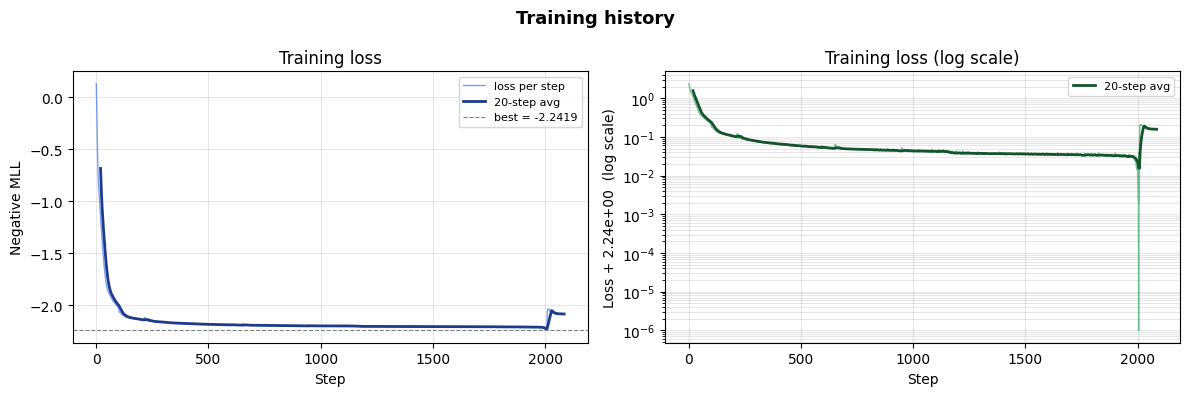

In [12]:
# ============================================================
# TRAINING HISTORY PLOT
# ============================================================
 
fig_hist, ax_hist = plt.subplots(1, 2, figsize=(12, 4))
 
steps = range(1, len(loss_history) + 1)
 
# --- left panel: raw loss ---
ax_hist[0].plot(steps, loss_history, color="#2563eb", linewidth=1.0, alpha=0.6,
                label="loss per step")
# smoothed trend (running mean over 20 steps)
window_sm = 20
if len(loss_history) >= window_sm:
    smooth = np.convolve(loss_history,
                         np.ones(window_sm) / window_sm,
                         mode="valid")
    ax_hist[0].plot(range(window_sm, len(loss_history) + 1), smooth,
                    color="#1e3a8a", linewidth=2.0, label=f"{window_sm}-step avg")
ax_hist[0].axhline(min(loss_history), color="gray", linewidth=0.8,
                   linestyle="--", label=f"best = {min(loss_history):.4f}")
ax_hist[0].set_xlabel("Step")
ax_hist[0].set_ylabel("Negative MLL")
ax_hist[0].set_title("Training loss")
ax_hist[0].legend(fontsize=8)
ax_hist[0].grid(True, alpha=0.3)
 
# --- right panel: log-scale loss (highlights late-stage convergence) ---
log_loss = np.array(loss_history)
# shift so values are positive before taking log (loss can be negative)
shift = max(0.0, -log_loss.min()) + 1e-6
ax_hist[1].plot(steps, log_loss + shift, color="#16a34a", linewidth=1.0,
                alpha=0.6)
if len(loss_history) >= window_sm:
    smooth_shifted = smooth + shift
    ax_hist[1].plot(range(window_sm, len(loss_history) + 1), smooth_shifted,
                    color="#14532d", linewidth=2.0, label=f"{window_sm}-step avg")
ax_hist[1].set_yscale("log")
ax_hist[1].set_xlabel("Step")
ax_hist[1].set_ylabel(f"Loss + {shift:.2e}  (log scale)")
ax_hist[1].set_title("Training loss (log scale)")
ax_hist[1].legend(fontsize=8)
ax_hist[1].grid(True, alpha=0.3, which="both")
 
fig_hist.suptitle("Training history", fontsize=13, fontweight="bold")
fig_hist.tight_layout()
fig_hist.show()